In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
stores = pd.read_csv("stores.csv")

In [3]:
holidays = pd.read_csv("holidays.csv")
holidays

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba
...,...,...,...,...
345,2017-12-22,National,Ecuador,Navidad-3
346,2017-12-23,National,Ecuador,Navidad-2
347,2017-12-24,National,Ecuador,Navidad-1
348,2017-12-25,National,Ecuador,Navidad


In [4]:
oil = pd.read_csv("oil.csv")
oil

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


In [5]:
stores = pd.read_csv("stores.csv")
stores

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas
5,6,Quito,Pichincha
6,7,Quito,Pichincha
7,8,Quito,Pichincha
8,9,Quito,Pichincha
9,10,Quito,Pichincha


In [6]:
df = pd.read_csv("timeseries.csv")

In [7]:
df

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
447,2014-03-27,328.0
448,2014-03-28,523.0
449,2014-03-29,647.0
450,2014-03-30,599.0


In [8]:
pd.to_datetime(df['date'])

0     2013-01-02
1     2013-01-03
2     2013-01-04
3     2013-01-05
4     2013-01-06
         ...    
447   2014-03-27
448   2014-03-28
449   2014-03-29
450   2014-03-30
451   2014-03-31
Name: date, Length: 452, dtype: datetime64[us]

In [ ]:
df['date'] = pd.to_datetime(df['date'])  #Date format check
df.set_index('date', inplace=True) #set as index

In [10]:
df

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [11]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
DatetimeIndex: 452 entries, 2013-01-02 to 2014-03-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  452 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


unit_sales    0
dtype: int64

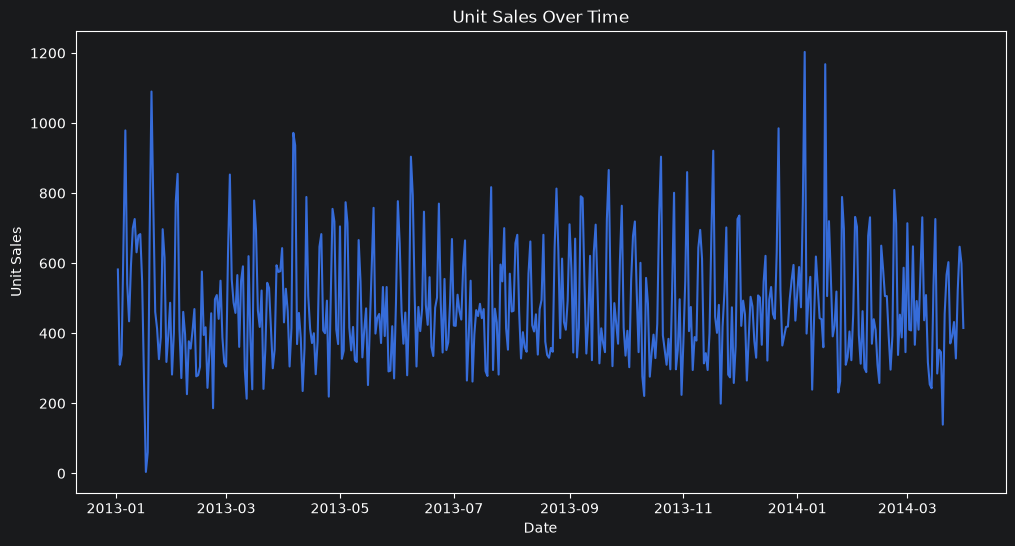

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df.index,
         df["unit_sales"])

plt.title("Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit Sales")

plt.show()
# No clear long-term trend, High day-to-day variability, Several prominent spikes, The time series appears continuous,Possible seasonal patterns (additional analyses are required)


In [13]:
# Outlier Detection
df['unit_sales']


date
2013-01-02    582.0
2013-01-03    310.0
2013-01-04    338.0
2013-01-05    654.0
2013-01-06    979.0
              ...  
2014-03-27    328.0
2014-03-28    523.0
2014-03-29    647.0
2014-03-30    599.0
2014-03-31    415.0
Name: unit_sales, Length: 452, dtype: float64

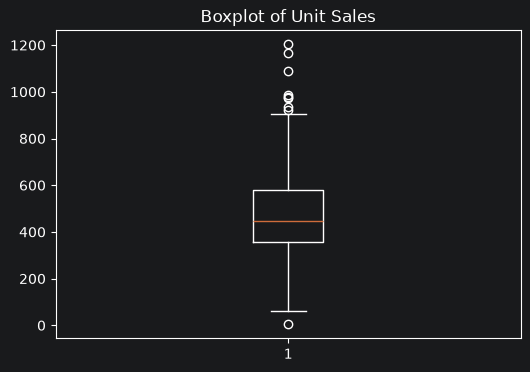

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['unit_sales'])
plt.title("Boxplot of Unit Sales")
plt.show()

In [15]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['unit_sales']))
outliers = df[z_scores > 3]
outliers

# Potential outliers were identified using the Z-score method. Since this is a sales forecasting problem, extreme values may represent genuine business events (e.g., promotions or holidays) rather than data errors. Therefore, detected outliers should be reviewed before deciding whether to remove them.

,unit_sales
date,
2013-01-20,1090.0
2014-01-05,1203.0
2014-01-16,1168.0


In [16]:
mean = df['unit_sales'].mean()
sigma = df['unit_sales'].std()

print("Mean:", mean)
print("Standard deviation:", sigma)

Mean: 480.0907079646018
Standard deviation: 170.83977582628623


In [17]:
holidays['date'] = pd.to_datetime(holidays['date'])

In [18]:
holidays.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[us]
 1   locale       350 non-null    str           
 2   locale_name  350 non-null    str           
 3   description  350 non-null    str           
dtypes: datetime64[us](1), str(3)
memory usage: 11.1 KB


In [19]:
outliers_holidays = outliers.reset_index().merge(
    holidays,
    on="date",
    how="left"
)

outliers_holidays

,date,unit_sales,locale,locale_name,description
0,2013-01-20,1090.0,NaN,NaN,NaN
1,2014-01-05,1203.0,NaN,NaN,NaN
2,2014-01-16,1168.0,NaN,NaN,NaN


In [20]:
outliers_holidays

,date,unit_sales,locale,locale_name,description
0,2013-01-20,1090.0,NaN,NaN,NaN
1,2014-01-05,1203.0,NaN,NaN,NaN
2,2014-01-16,1168.0,NaN,NaN,NaN


In [21]:
holidays[
    (holidays['date'] >= '2014-01-01') &
    (holidays['date'] <= '2014-01-10')
]

,date,locale,locale_name,description
92,2014-01-01,National,Ecuador,Primer dia del ano


In [22]:
holidays[
    (holidays['date'] >= '2014-01-10') &
    (holidays['date'] <= '2014-01-20')
]

,date,locale,locale_name,description


In [23]:
# The identified outliers were compared with the holiday calendar. No direct matches were found between the outlier dates and official holidays. Additionally, no relevant holidays were observed in the immediate surrounding period, except for New Year's Day, which occurred several days before one of the detected outliers. Therefore, the extreme sales values cannot be directly explained by the available holiday information and may instead be associated with other business factors, such as promotions or unusual customer demand.

In [24]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

# No missing values were found in the unit_sales column. Therefore, no imputation was required before further analysis.

unit_sales    0
dtype: int64

In [25]:
df.index.max()

Timestamp('2014-03-31 00:00:00')

In [26]:
df.index.min()

Timestamp('2013-01-02 00:00:00')

In [27]:
pd.date_range(start=df.index.min(), end=df.index.max())

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', length=454, freq='D')

In [28]:
df.index

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', name='date', length=452, freq=None)

In [29]:
# all days 454, in database 452 = 2 days are missing

In [30]:
# Create a complete daily date range
date_range = pd.date_range(df.index.min(), df.index.max(), freq='D')

# Add missing dates
df = df.reindex(date_range)

# Fill missing sales with zero
df['unit_sales'] = df['unit_sales'].fillna(0)

In [31]:
df.loc['2013-12-25':'2014-01-01']

,unit_sales
2013-12-25,0.0
2013-12-26,418.0
2013-12-27,419.0
2013-12-28,499.0
2013-12-29,552.0
2013-12-30,595.0
2013-12-31,436.0
2014-01-01,0.0


In [32]:
df[df['unit_sales'].isna()]
# Two calendar dates were missing from the original time series. After reindexing the dataset to a complete daily date range, these dates were added with missing values (NaN). Since the task requires missing dates to represent days with no sales, the missing observations were replaced with zero sales.

,unit_sales


In [33]:
# Summary Statistics
summary_stats = df['unit_sales'].describe()
summary_stats

count     454.000000
mean      477.975771
std       173.408453
min         0.000000
25%       356.500000
50%       443.500000
75%       576.750000
max      1203.000000
Name: unit_sales, dtype: float64

In [34]:
df.loc[['2013-12-25', '2014-01-01']]

,unit_sales
2013-12-25,0.0
2014-01-01,0.0


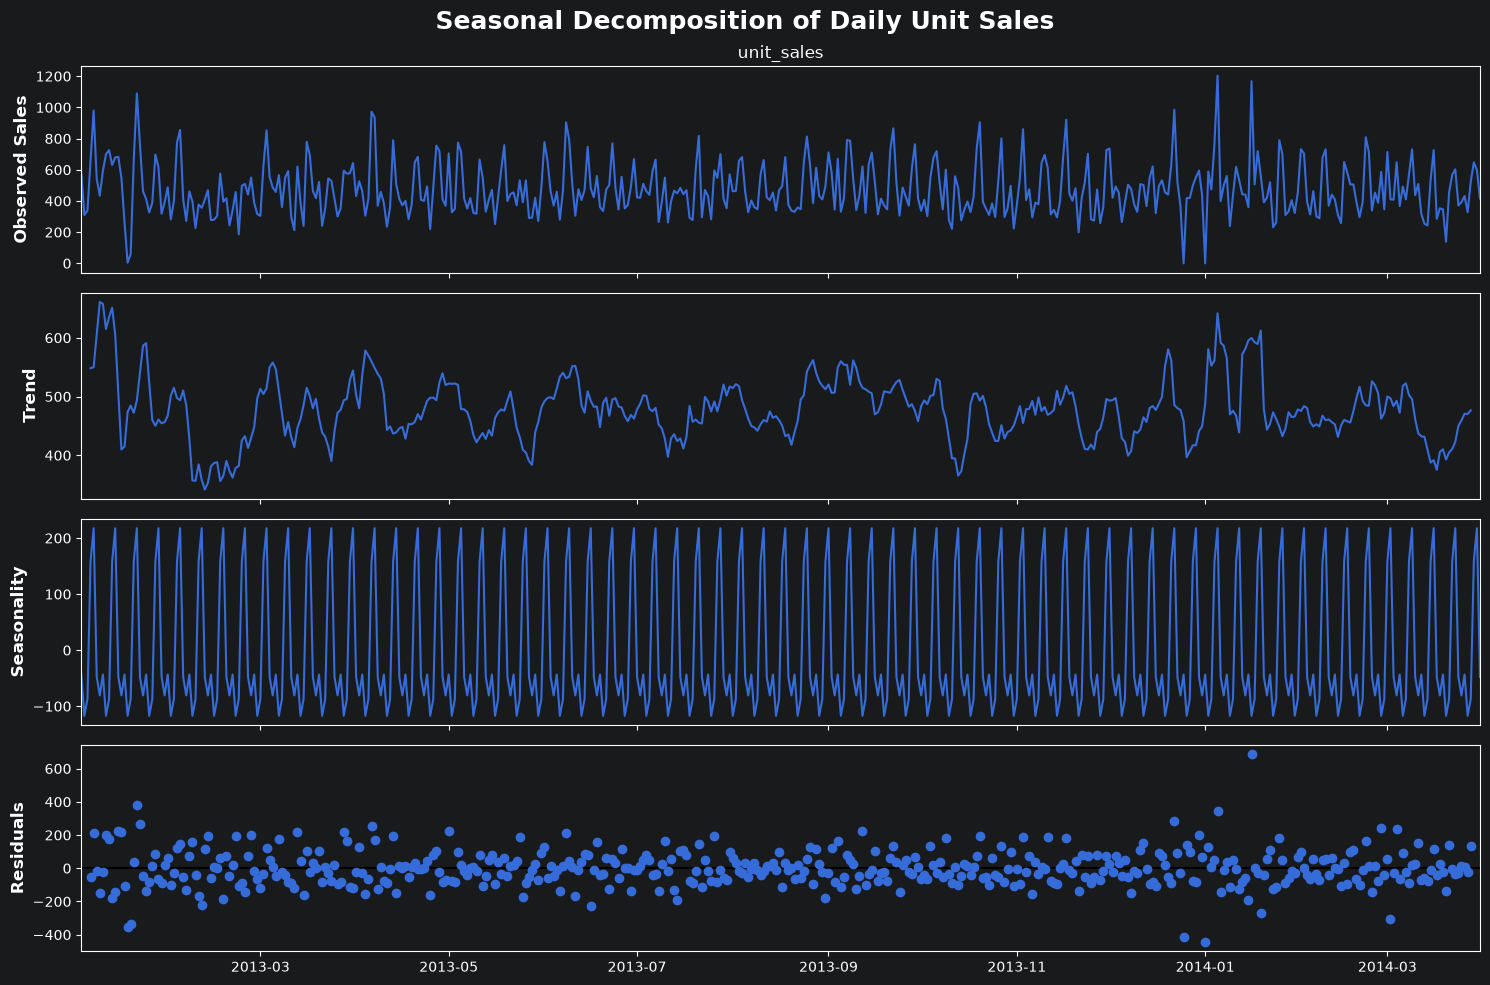

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(df['unit_sales'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(15, 10)

fig.suptitle(
    "Seasonal Decomposition of Daily Unit Sales",
    fontsize=18,
    fontweight="bold"
)

labels = [
    "Observed Sales",
    "Trend",
    "Seasonality",
    "Residuals"
]

for ax, label in zip(fig.axes, labels):
    ax.set_ylabel(label, fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()
# The time series is divided into four components: Observed, Trend, Seasonal, Residual
# The seasonal decomposition separates the time series into trend, seasonal, and residual components. The trend component shows moderate fluctuations without a clear long-term increase or decrease. A repeating seasonal pattern is visible, indicating recurring sales behaviour. The residual component mainly contains random variation after removing trend and seasonality.

In [41]:
# Stationary Test
from statsmodels.tsa.stattools import adfuller
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['unit_sales'])
adf_result[1]



np.float64(4.441049433078314e-06)

In [42]:
from statsmodels.tsa.stattools import adfuller
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['unit_sales'])
adf_result_dict = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1],
    'Critical Values': adf_result[4]
}
adf_result_dict
# The Augmented Dickey–Fuller test returned a p-value below 0.05, indicating that the null hypothesis of a unit root can be rejected. Therefore, the sales series can be considered stationary. Needed for ARIMA and SARIMA

{'ADF Statistic': np.float64(-5.3437722401479535),
 'p-value': np.float64(4.441049433078314e-06),
 'Critical Values': {'1%': np.float64(-3.4454725477848998),
  '5%': np.float64(-2.8682072297316794),
  '10%': np.float64(-2.570321396485665)}}

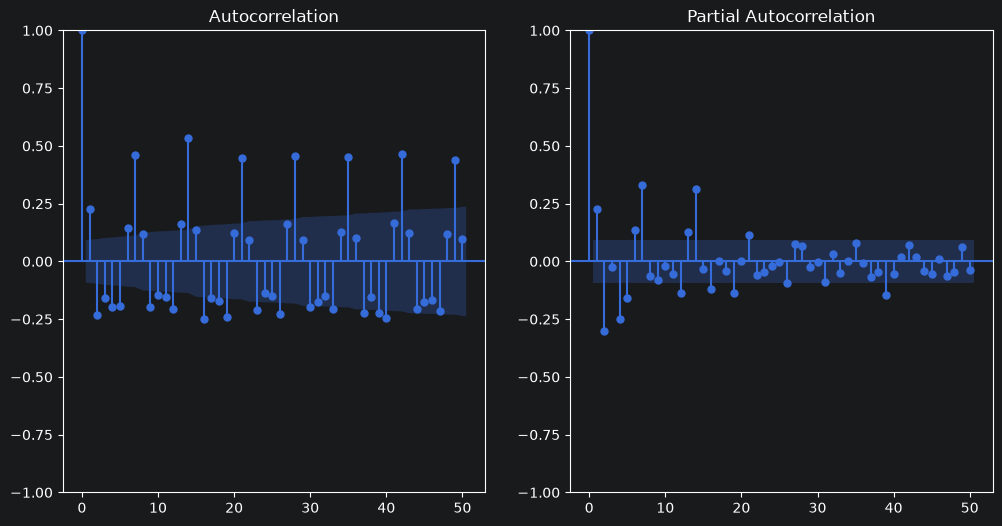

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['unit_sales'], ax=plt.gca(), lags=50)
plt.subplot(122)
plot_pacf(df['unit_sales'], ax=plt.gca(), lags=50)
plt.show()

In [75]:
# Save the cleaned data
df.index.name = "date"
df.to_csv("cleaned_timeseries.csv", index=True)



In [76]:
# Keep only the cleaned sales data
df_clean = df[['unit_sales']].copy()

# Save the cleaned dataset
df_clean.to_csv("cleaned_timeseries.csv", index=True)

## Weekdays

In [47]:
df['day_of_week'] = df.index.day_name()

In [48]:
df[['day_of_week', 'unit_sales']].head()

,day_of_week,unit_sales
date,,
2013-01-02,Wednesday,582.0
2013-01-03,Thursday,310.0
2013-01-04,Friday,338.0
2013-01-05,Saturday,654.0
2013-01-06,Sunday,979.0


In [49]:
weekday_sales = (
    df.groupby('day_of_week')['unit_sales']
      .mean()
      .reindex([
          'Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
)

weekday_sales

day_of_week
Monday       429.969231
Tuesday      397.718750
Wednesday    437.092308
Thursday     359.661538
Friday       389.230769
Saturday     636.830769
Sunday       694.092308
Name: unit_sales, dtype: float64

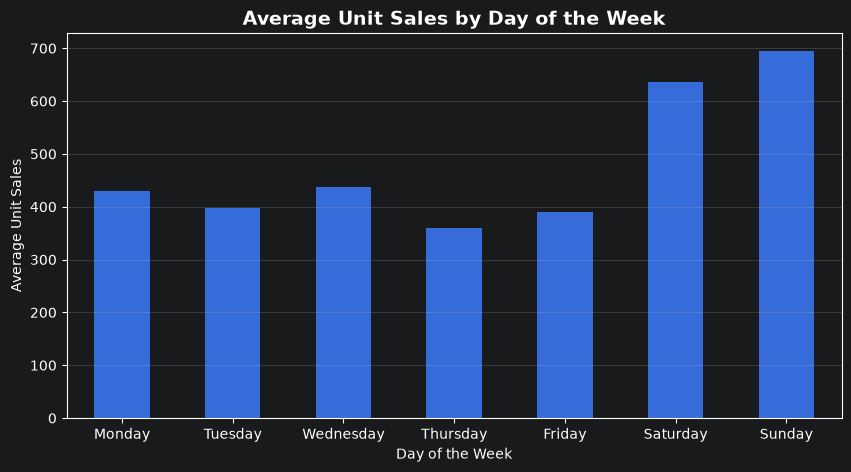

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

weekday_sales.plot(kind='bar')

plt.title("Average Unit Sales by Day of the Week",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Day of the Week")
plt.ylabel("Average Unit Sales")

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

 ## Day of the Week Analysis
 Average daily sales vary considerably across the days of the week. Sales are relatively stable during weekdays, ranging from approximately 360 to 440 units per day. In contrast, sales increase substantially during the weekend, reaching an average of 637 units on Saturday and 694 units on Sunday.
 This indicates a clear weekly seasonal pattern, suggesting that customer purchasing behaviour changes significantly on weekends. Such recurring weekly seasonality is expected to improve forecasting performance when using Prophet, which models weekly seasonal effects automatically.

## Oil Price Analysis

In [52]:
oil['date'] = pd.to_datetime(oil['date'])

In [53]:
oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[us]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 19.2 KB


In [58]:
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

The price of oil is not published every calendar day. For Saturday and Sunday, the most recently known retail price is often used. That's why 'ffill()' is a common practice for oil prices.

In [57]:
oil.isnull().sum()

date          0
dcoilwtico    1
dtype: int64

In [60]:
oil = oil.set_index('date')

df_oil = df.merge(
    oil,
    left_index=True,
    right_index=True,
    how='left'
)

df_oil.head()

,unit_sales,day_of_week,dcoilwtico
date,,,
2013-01-02,582.0,Wednesday,93.14
2013-01-03,310.0,Thursday,92.97
2013-01-04,338.0,Friday,93.12
2013-01-05,654.0,Saturday,NaN
2013-01-06,979.0,Sunday,NaN


In [61]:
df_oil.isnull().sum()

unit_sales       0
day_of_week      0
dcoilwtico     130
dtype: int64

In [62]:
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].ffill()

In [63]:
df_oil.isnull().sum()

unit_sales     0
day_of_week    0
dcoilwtico     0
dtype: int64

In [64]:
correlation = df_oil[['unit_sales', 'dcoilwtico']].corr()
print(correlation)

            unit_sales  dcoilwtico
unit_sales    1.000000    0.003497
dcoilwtico    0.003497    1.000000


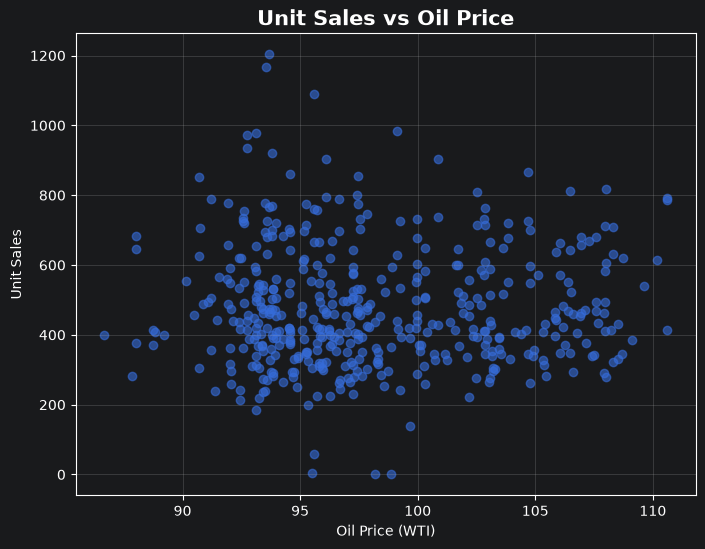

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_oil['dcoilwtico'],
    df_oil['unit_sales'],
    alpha=0.6
)

plt.title(
    "Unit Sales vs Oil Price",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Oil Price (WTI)")
plt.ylabel("Unit Sales")

plt.grid(alpha=0.3)

plt.show()

Oil Price Analysis Interpretation

The Pearson correlation coefficient between daily unit sales and the WTI oil price is 0.0035, indicating virtually no linear relationship between the two variables. The scatter plot confirms this finding, as the observations are randomly dispersed without any visible upward or downward trend. Based on this analysis, oil prices do not appear to have a meaningful direct influence on daily sales during the observed period.

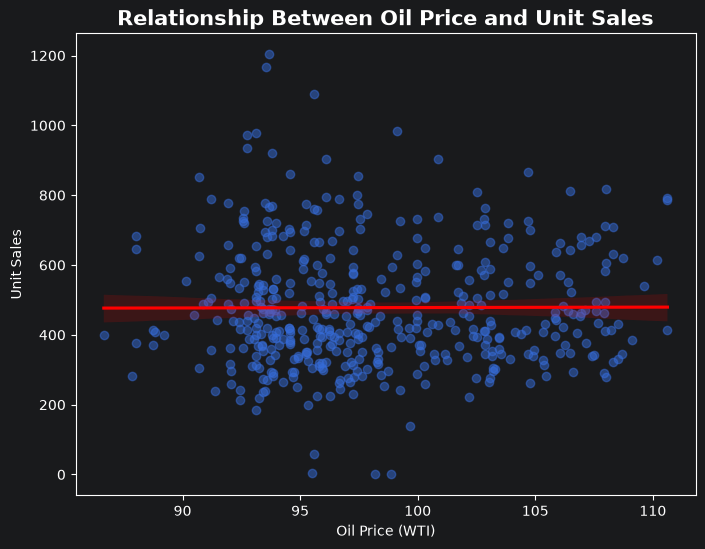

In [67]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_oil,
    x='dcoilwtico',
    y='unit_sales',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Relationship Between Oil Price and Unit Sales",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Oil Price (WTI)")
plt.ylabel("Unit Sales")

plt.show()

The regression line (red) makes the statement very clear

In [68]:
holidays['date'] = pd.to_datetime(holidays['date'])

In [69]:
# Copy the sales data
df_holiday = df.copy()

# Create Holiday indicator
df_holiday['is_holiday'] = df_holiday.index.isin(holidays['date'])

In [70]:
df_holiday[['unit_sales', 'is_holiday']].head()

,unit_sales,is_holiday
date,,
2013-01-02,582.0,False
2013-01-03,310.0,False
2013-01-04,338.0,False
2013-01-05,654.0,True
2013-01-06,979.0,False


In [71]:
# Compare average sales
holiday_sales = (
    df_holiday.groupby('is_holiday')['unit_sales']
    .mean()
)

holiday_sales

is_holiday
False    476.390123
True     491.081633
Name: unit_sales, dtype: float64

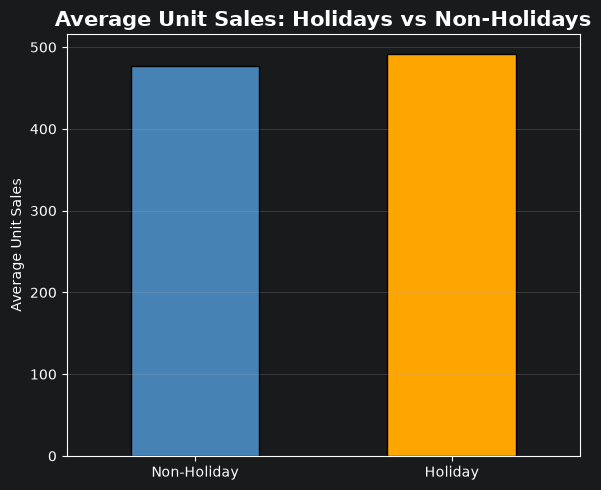

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

holiday_sales.plot(
    kind='bar',
    color=['steelblue', 'orange'],
    edgecolor='black'
)

plt.title(
    "Average Unit Sales: Holidays vs Non-Holidays",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("")
plt.ylabel("Average Unit Sales")
plt.xticks([0,1], ['Non-Holiday','Holiday'], rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

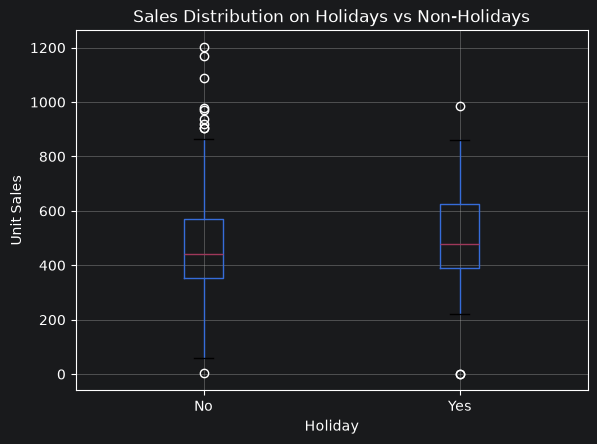

In [73]:
plt.figure(figsize=(7,5))

df_holiday.boxplot(
    column='unit_sales',
    by='is_holiday'
)

plt.title("Sales Distribution on Holidays vs Non-Holidays")
plt.suptitle("")
plt.xlabel("Holiday")
plt.ylabel("Unit Sales")

plt.xticks([1,2], ['No','Yes'])

plt.show()

### Holiday Impact Analysis

Daily sales were compared between holidays and non-holidays using the holiday calendar provided in the dataset. Average sales on holidays were approximately 491 units, compared to 476 units on non-holidays. Although holiday sales are slightly higher, the difference is relatively small.

The boxplot shows a similar distribution of sales for both groups, with comparable medians, variability, and outliers. Overall, the analysis suggests that holidays have only a limited impact on daily unit sales during the observed period.

In [74]:
stores.head()

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


Limitation

The stores.csv dataset provides information about store locations. However, the sales data used in this project are aggregated at the daily level and do not contain store identifiers (store_nbr). Therefore, it is not possible to analyse the effects of local or regional holidays on individual stores. Consequently, all holidays were treated as a single category in the holiday impact analysis.

## EDA Summary

The exploratory data analysis showed that the dataset is complete after handling missing calendar dates and contains only a few extreme sales observations, which likely correspond to genuine business events rather than data errors. A clear weekly seasonal pattern was identified, with significantly higher sales on weekends, especially on Sundays. Seasonal decomposition confirmed recurring seasonal behaviour and a relatively stable long-term trend. The analysis of oil prices revealed virtually no linear relationship with daily sales, suggesting that oil prices are unlikely to be a strong predictor. Holiday sales were slightly higher than sales on non-holidays; however, the overall effect was relatively small. These findings provide valuable insights into the sales dynamics and support the development of a forecasting model using Prophet.